In [54]:
%run 0_config.ipynb

In [32]:
L = 10; it = 600; trained_params_list = []; parameters_list = [];iii = [] 
g_run_cc_energy,r_out, paths = rbm_fe(0,L,it,True,4)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

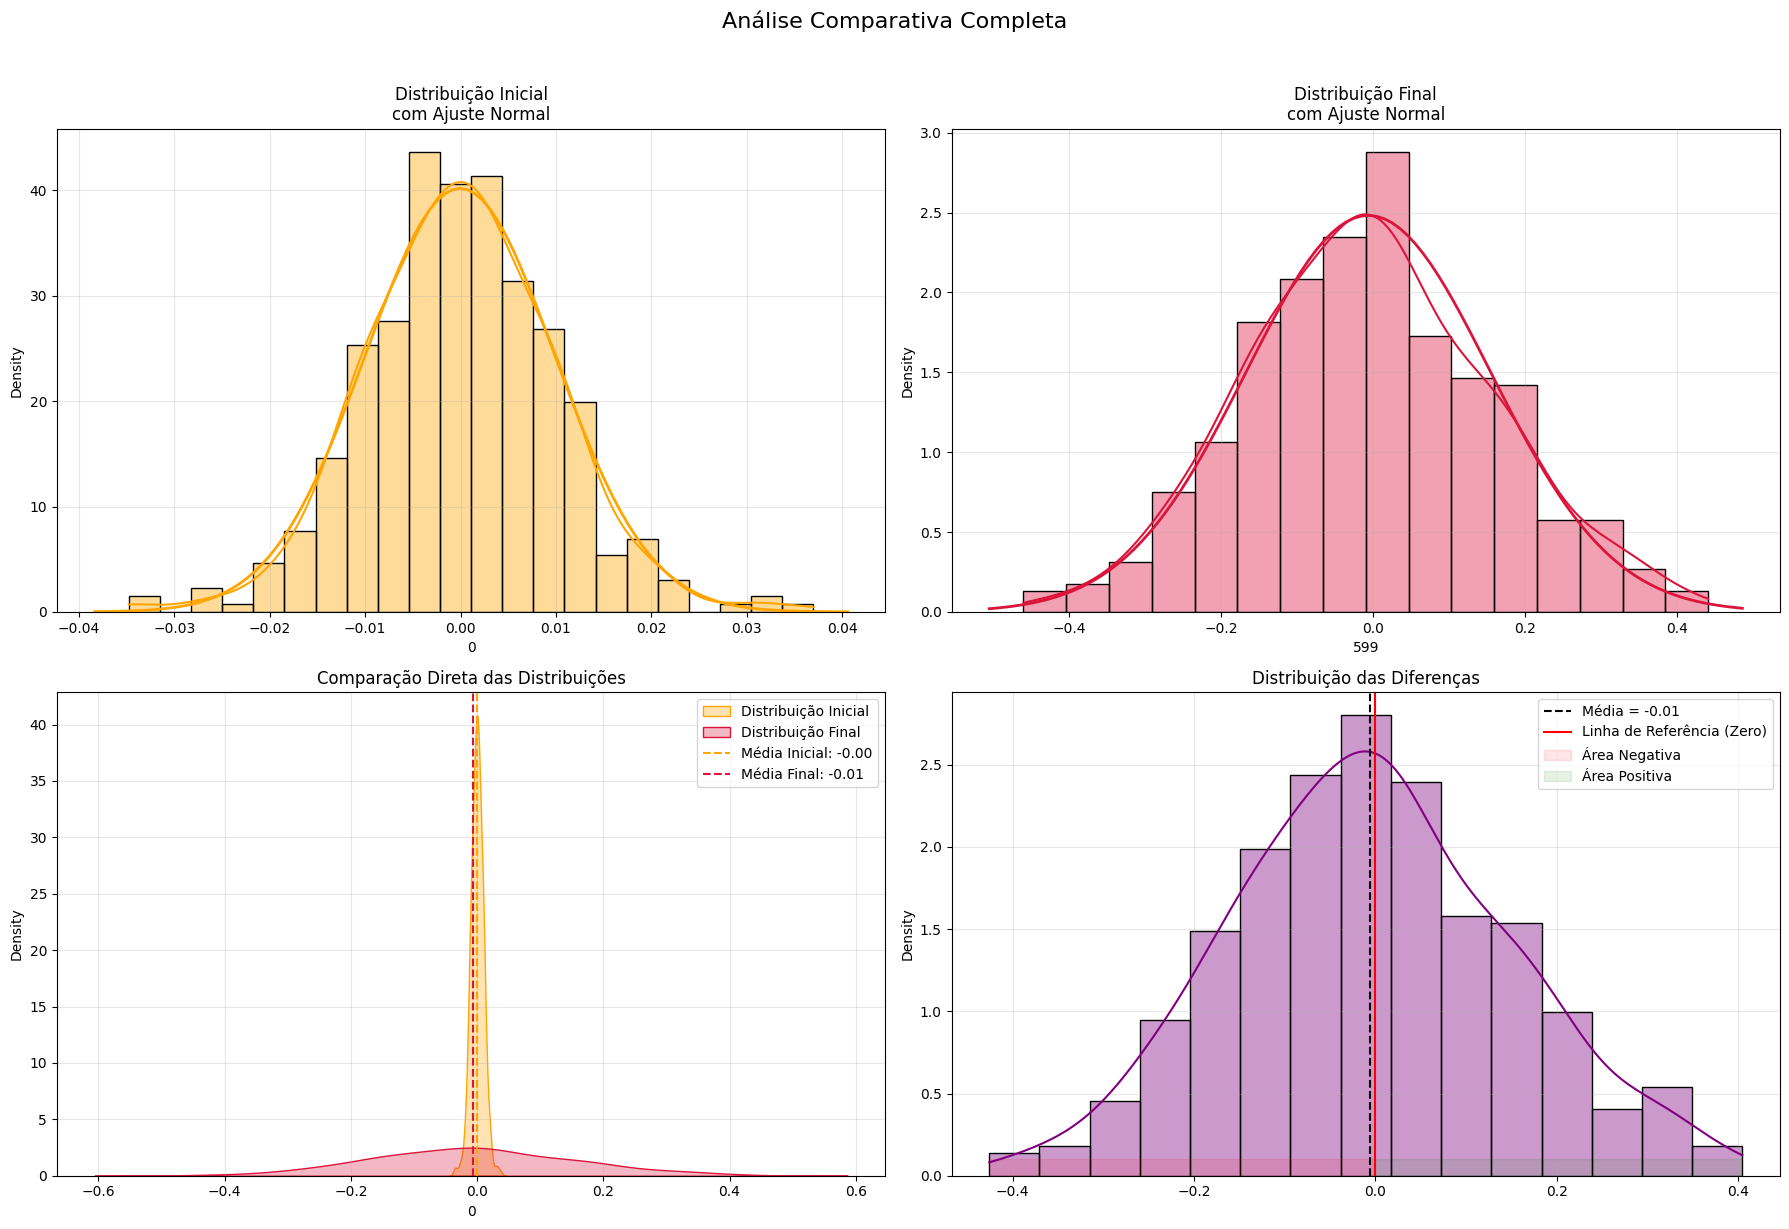

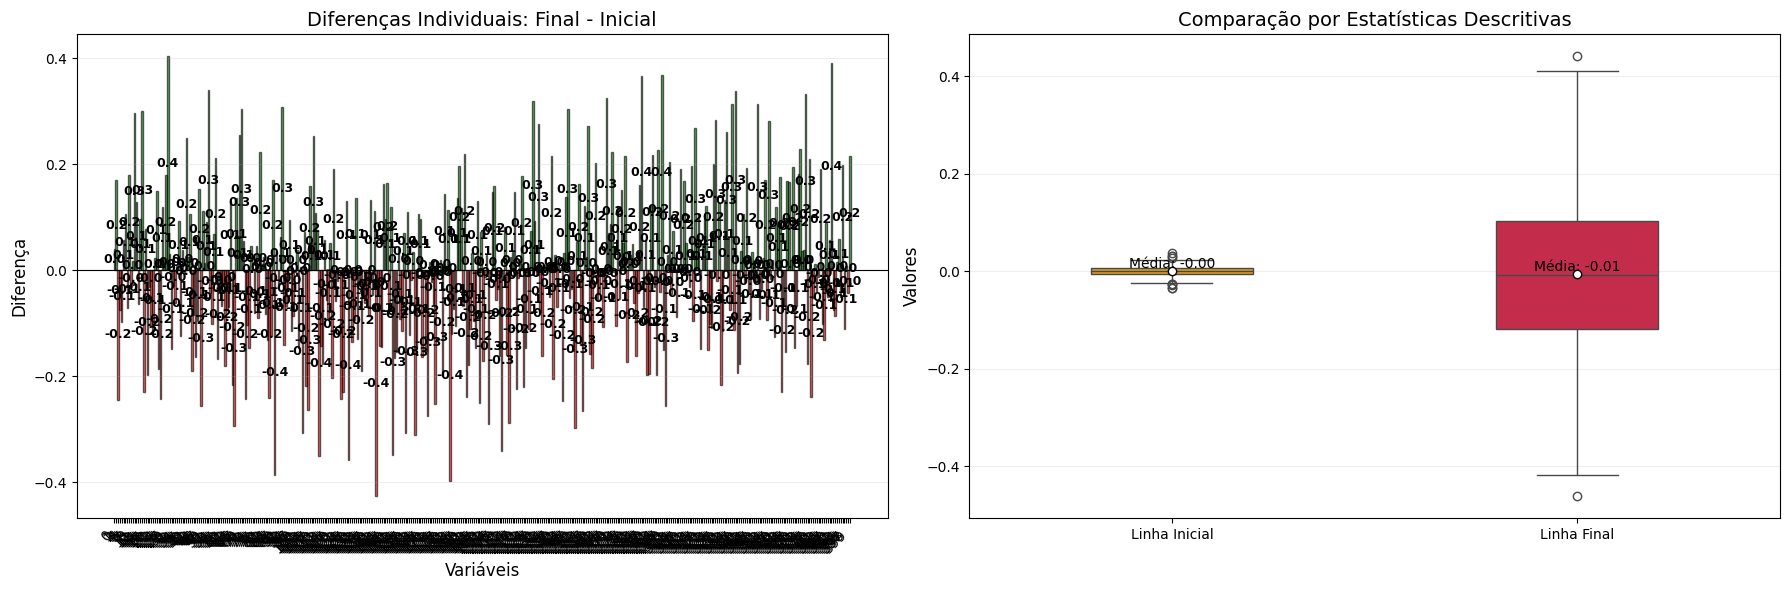

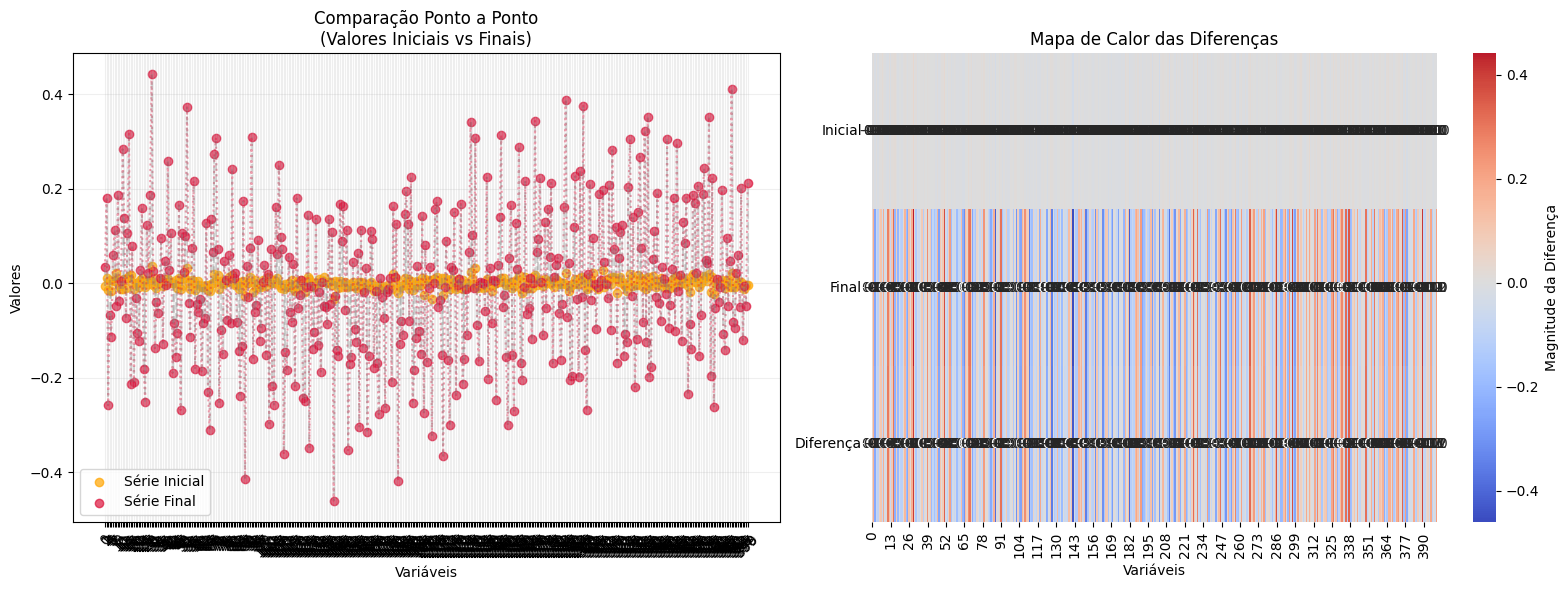


Métricas Estatísticas:
----------------------
Média da diferença: -0.01
Desvio padrão da diferença: 0.15
Tamanho do efeito (Cohen's d): -0.04
Magnitude da diferença (norma L2): 3.10


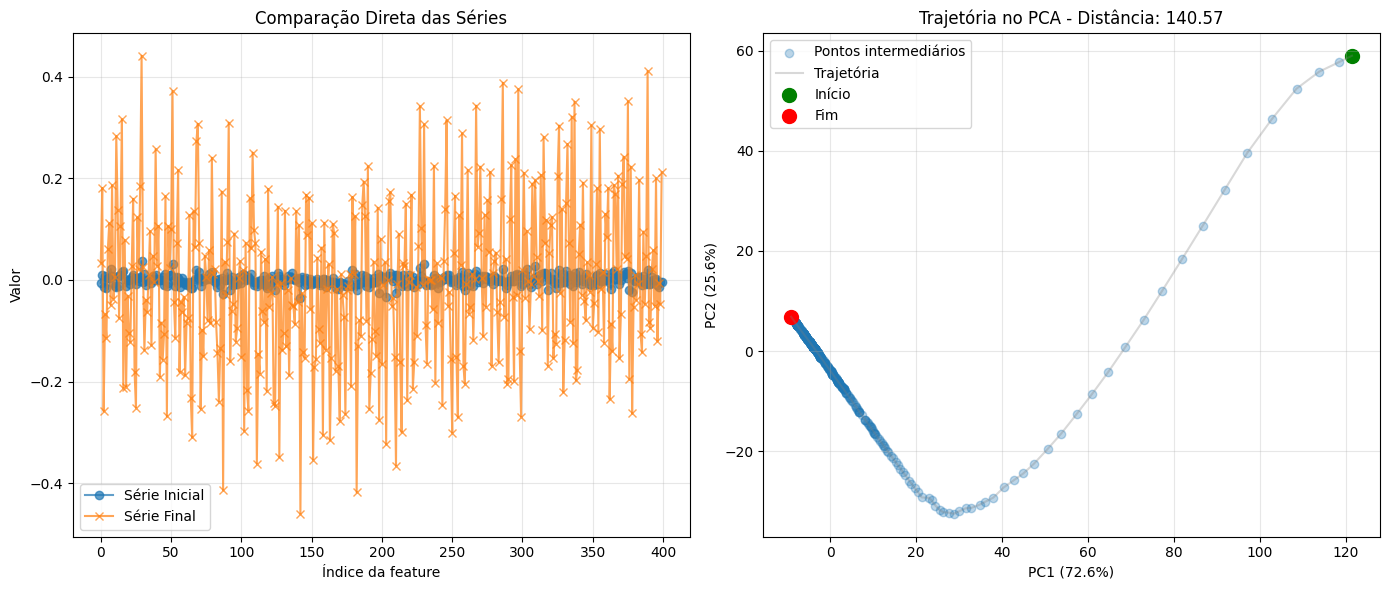

In [51]:
plots_n(paths, False, 0, -1)

In [55]:
L = 10; it = 600; trained_params_list = []; parameters_list = [];iii = [] 
g_run_cc_energy,r_out, paths = rbm(1,L,it,True,1)

NameError: name 'model' is not defined

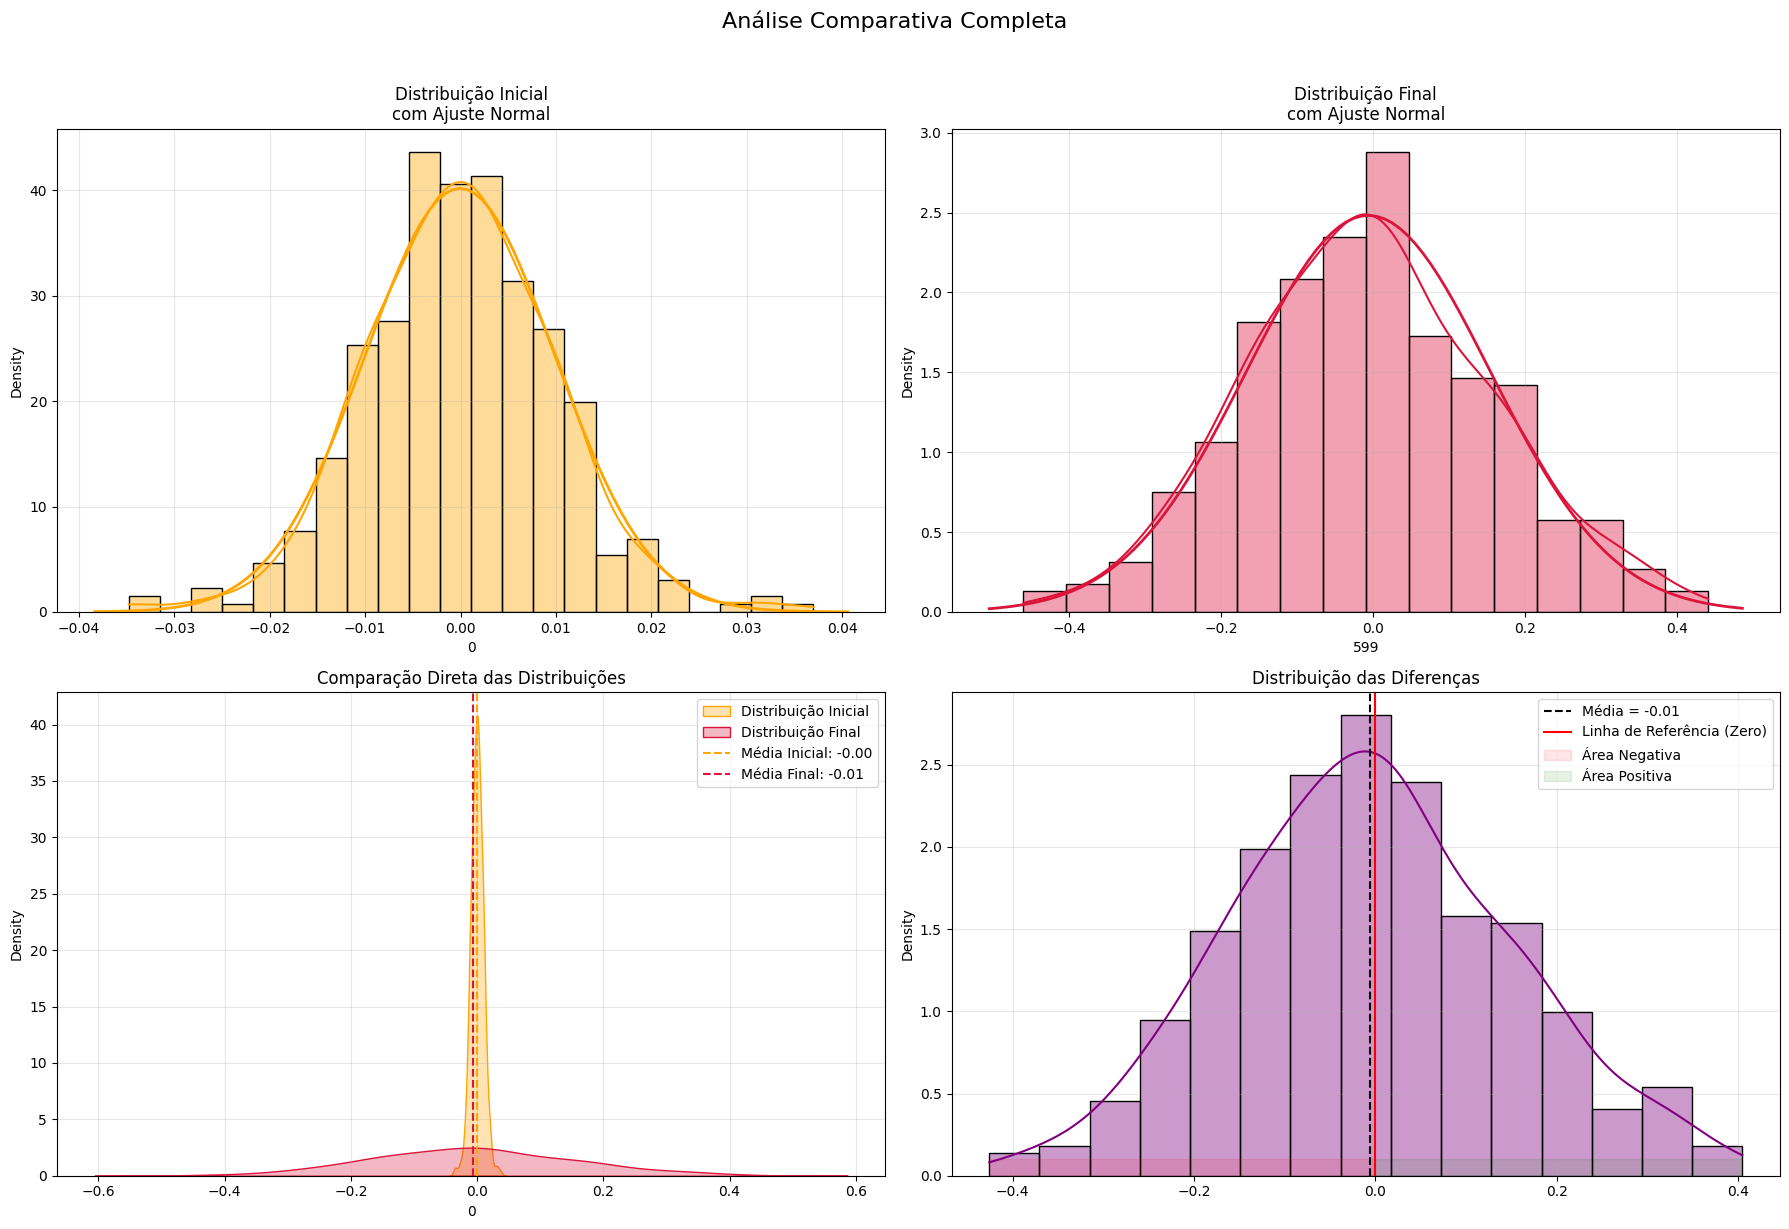

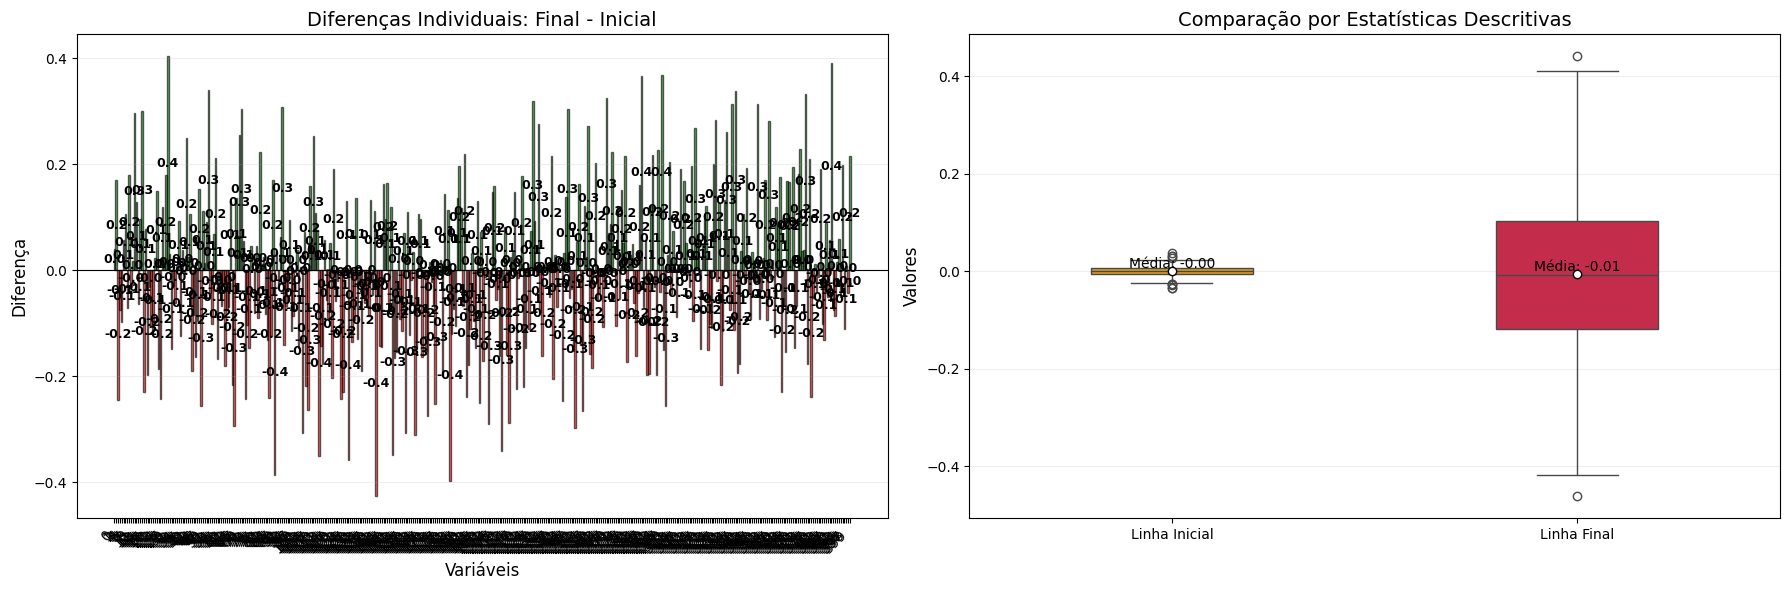

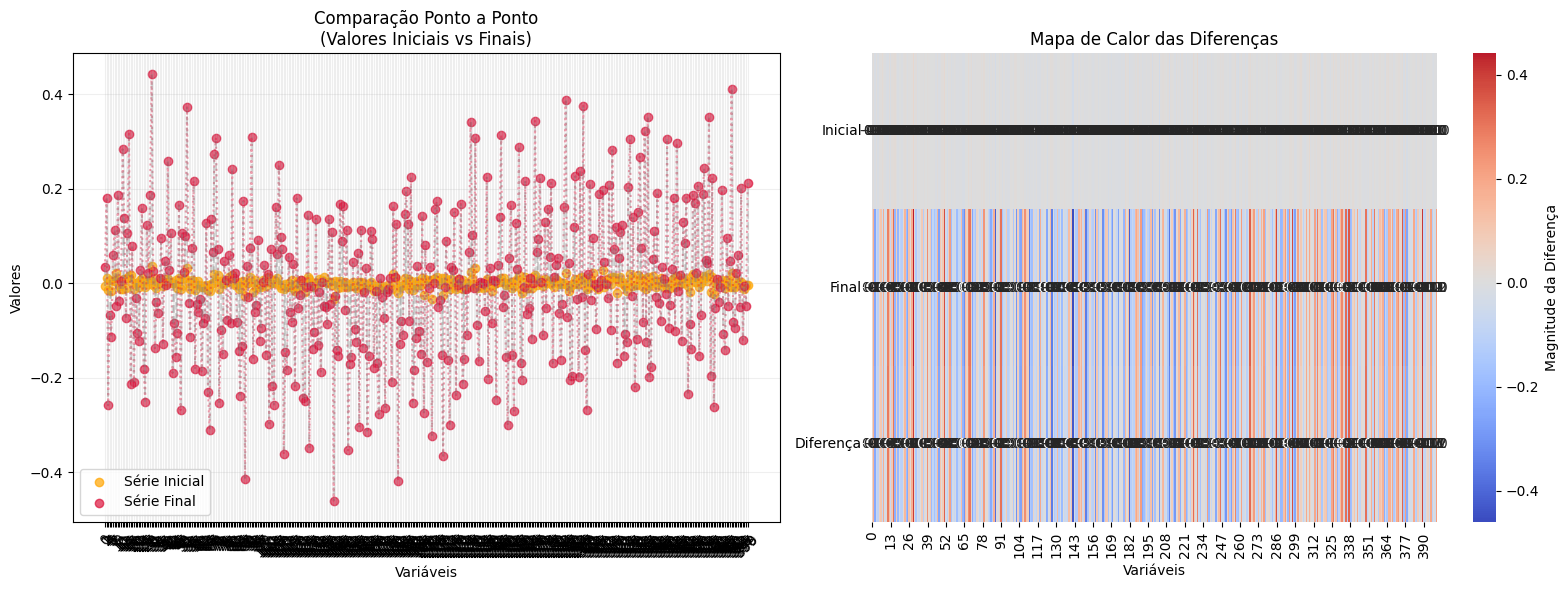


Métricas Estatísticas:
----------------------
Média da diferença: -0.01
Desvio padrão da diferença: 0.15
Tamanho do efeito (Cohen's d): -0.04
Magnitude da diferença (norma L2): 3.10


In [33]:
plotdx(paths, False, 0, -1)

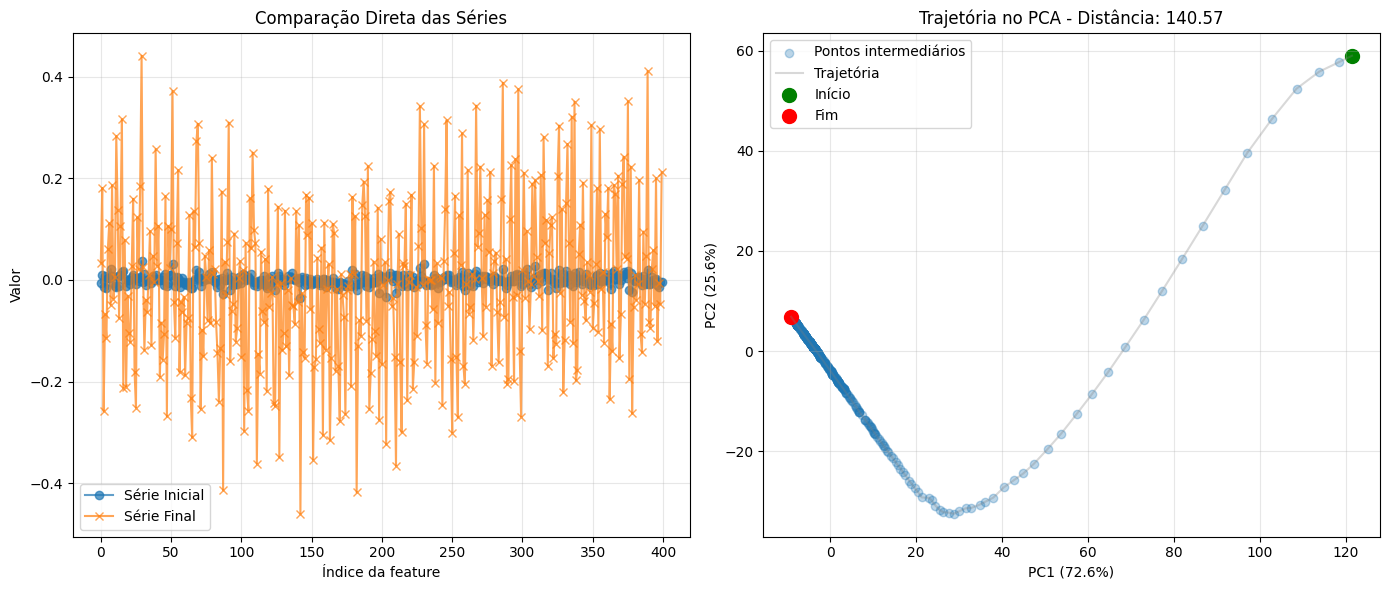

In [49]:
plotdp(paths, False, 0, -1)

In [ ]:
for L in range(2,11,2):
    mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
    print(L,mens,exact_gs_energy)

In [ ]:
for L in range(2,7,2):
    exact_gs_energy,r_out = jastrow_calc(0,L,600,True)
    print("L:", L, " | ",mens,exact_gs_energy)

In [ ]:
for L in range(2,7,2):
    g_run,r_out = rbm(0,L,1200,True)
    print("L:", L, " | ",mens,float(g_run.energy.mean.real))

Esse é o <b< Hamiltoniano ferromagnético </b>, mas a RBM foi projetada originalmente para representar estados altamente correlacionados como os antiferromagnéticos — e não estados trivialmente alinhados como o ferromagnético.

In [ ]:
for L in range(2,7,2):
    g_run,r_out = rbm_fe(0,L,600,True,)
    print("L:", L, " | ",mens,float(g_run.energy.mean.real))

- Espaço de Hilbert completo (o modelo pode acessar o setor $ S^z = +N/2$ <br />
- sampler que explora todos os setores <br />
- otimizador funcional <br />
- A RBM é capaz de aprender que o estado de menor energia é o com todos os spins alinhados, o que é trivial para ela (uma configuração dominante)

In [ ]:
%run 0_config.ipynb

In [ ]:
df_kernel_real = pd.read_csv(paths[2])
df = df_kernel_real

In [ ]:


# Cria uma figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da diferença
axes[2].bar(diferenca.index, diferenca.values, 
            color=np.where(diferenca.values >= 0, 'green', 'red'),  # Verde para positivo, vermelho para negativo
            edgecolor='black')
axes[2].set_title("Diferença (Final - Inicial)", fontsize=12)
axes[2].set_xlabel("Variáveis", fontsize=10)
axes[2].tick_params(axis='x', rotation=90)
axes[2].grid(axis='y', lw=0.3, ls='--', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)  # Linha no zero para referência

# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import matplotlib.gridspec as gridspec

In [ ]:
# --- Seleciona os dados ---
linha1 = df.iloc[0].iloc[1:]          # Primeira linha sem a primeira coluna
ultima_linha = df.iloc[-1].iloc[1:]   # Última linha sem a primeira coluna
diff = ultima_linha - linha1          # Diferença final - inicial

# --- Prepara a figura com 3 gráficos em linha ---
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])

# --- 1. Gráfico: distribuição inicial ---
ax0 = fig.add_subplot(gs[0])
colors0 = plt.cm.coolwarm((linha1.values - (-1)) / 2)  # normaliza -1 a 1 para [0,1]
ax0.bar(linha1.index, linha1.values, color=colors0, edgecolor='black')
for i, v in enumerate(linha1.values):
    ax0.text(i, v + 0.02 * np.sign(v), f"{v:.2f}", ha='center', fontsize=8)
ax0.set_ylim(-1.05, 1.05)
ax0.set_title("Distribuição Inicial", fontsize=12)
ax0.set_xlabel("Variáveis"); ax0.set_ylabel("Valor")
ax0.tick_params(axis='x', rotation=90)
ax0.grid(axis='y', linestyle='--', lw=0.3, alpha=0.7)

# --- 2. Gráfico: distribuição final ---
ax1 = fig.add_subplot(gs[1])
colors1 = plt.cm.coolwarm((ultima_linha.values - (-1)) / 2)
ax1.bar(ultima_linha.index, ultima_linha.values, color=colors1, edgecolor='black')
for i, v in enumerate(ultima_linha.values):
    ax1.text(i, v + 0.02 * np.sign(v), f"{v:.2f}", ha='center', fontsize=8)
ax1.set_ylim(-1.05, 1.05)
ax1.set_title("Distribuição Final", fontsize=12)
ax1.set_xlabel("Variáveis")
ax1.tick_params(axis='x', rotation=90)
ax1.grid(axis='y', linestyle='--', lw=0.3, alpha=0.7)

# --- 3. Gráfico: diferença entre final e inicial ---
ax2 = fig.add_subplot(gs[2])
ax2.bar(diff.index, diff.values, color='purple', edgecolor='black')
for i, v in enumerate(diff.values):
    ax2.text(i, v + 0.01 * np.sign(v), f"{v:.2f}", ha='center', fontsize=8)
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_ylim(-0.5, 0.5)
ax2.set_title("Mudança Final - Inicial", fontsize=12)
ax2.set_xlabel("Variáveis")
ax2.tick_params(axis='x', rotation=90)
ax2.grid(axis='y', linestyle='--', lw=0.3, alpha=0.7)

# --- Layout final ---
plt.suptitle("Comparação entre Interações Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# Pega a primeira e última linha, ignorando a primeira coluna
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Cria uma figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)



# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
L = 22; it = 600; trained_params_list = []; parameters_list = [];iii = [] 
g_run_cc_energy,r_out, paths = rbm_fe(0,L,it,True,1)

In [ ]:
df.shape

In [ ]:
!pip install plotly

In [ ]:

# Supondo que:
# linha1 = valores iniciais (ex: pd.Series)
# ultima_linha = valores finais
diferenca = ultima_linha - linha1

# Cria figura com 3 subplots no estilo "distribuição"
plt.figure(figsize=(15, 5))

# Subplot 1: Distribuição Inicial
plt.subplot(1, 3, 1)
sns.kdeplot(linha1, color='orange', fill=True, alpha=0.5)
plt.title('Distribuição Inicial', fontsize=12)
plt.xlabel('Valores')
plt.grid(alpha=0.3)

# Subplot 2: Distribuição Final
plt.subplot(1, 3, 2)
sns.kdeplot(ultima_linha, color='crimson', fill=True, alpha=0.5)
plt.title('Distribuição Final', fontsize=12)
plt.xlabel('Valores')
plt.grid(alpha=0.3)

# Subplot 3: Diferenças
plt.subplot(1, 3, 3)
sns.kdeplot(diferenca, color='purple', fill=True, alpha=0.5)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribuição das Diferenças', fontsize=12)
plt.xlabel('Diferença (Final - Inicial)')
plt.grid(alpha=0.3)

plt.suptitle('Comparação em Formato de Distribuição', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import norm

plt.figure(figsize=(15, 5))

# Função para plotar com overlay de curva normal
def plot_with_normal(ax, data, color, title):
    sns.histplot(data, kde=True, color=color, ax=ax, stat='density', alpha=0.4)
    mu, std = norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, color=color, linewidth=2)
    ax.set_title(title)
    ax.grid(alpha=0.3)

# Plotagem
ax1 = plt.subplot(1, 3, 1)
plot_with_normal(ax1, linha1, 'orange', 'Distribuição Inicial\ncom Ajuste Normal')

ax2 = plt.subplot(1, 3, 2)
plot_with_normal(ax2, ultima_linha, 'crimson', 'Distribuição Final\ncom Ajuste Normal')

ax3 = plt.subplot(1, 3, 3)
plot_with_normal(ax3, diferenca, 'purple', 'Diferenças\ncom Ajuste Normal')
ax3.axvline(0, color='black', linestyle='--')

plt.suptitle('Comparação com Aproximação Normal', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Cria DataFrame para plotagem
df_plot = pd.DataFrame({
    'Inicial': linha1,
    'Final': ultima_linha,
    'Diferença': diferenca
}).melt(var_name='Tipo', value_name='Valor')

# Plot
fig = px.histogram(df_plot, 
                   x='Valor', 
                   color='Tipo',
                   marginal='rug',
                   nbins=50,
                   facet_col='Tipo',
                   color_discrete_map={
                       'Inicial': 'orange',
                       'Final': 'crimson',
                       'Diferença': 'purple'
                   },
                   title='Distribuições Comparadas')

fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.7)
fig.show()

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Calcula diferenças
diferenca = ultima_linha - linha1

# Top 50 maiores diferenças (absolutas)
top_diff = diferenca.abs().nlargest(50).index
diferenca_top = diferenca[top_diff].sort_values()

# Cria figura com subplots
fig = make_subplots(rows=1, cols=3, 
                   subplot_titles=("Distribuição Inicial", 
                                  "Distribuição Final", 
                                  "Diferença (Final - Inicial)"))

# Adiciona traços
fig.add_trace(
    go.Bar(x=linha1[top_diff][diferenca_top.index],
           y=diferenca_top.index,
           orientation='h',
           name='Inicial',
           marker_color='orange'),
    row=1, col=1)

fig.add_trace(
    go.Bar(x=ultima_linha[top_diff][diferenca_top.index],
           y=diferenca_top.index,
           orientation='h',
           name='Final',
           marker_color='crimson'),
    row=1, col=2)

fig.add_trace(
    go.Bar(x=diferenca_top,
           y=diferenca_top.index,
           orientation='h',
           name='Diferença',
           marker_color=['green' if x >=0 else 'red' for x in diferenca_top]),
    row=1, col=3)

# Ajustes de layout
fig.update_layout(
    height=800,
    width=1400,
    title_text=f"Top 50 Variáveis com Maiores Diferenças (de {len(diferenca)} totais)",
    showlegend=False
)

# Ajusta eixos Y sincronizados
fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=2)
fig.update_yaxes(autorange="reversed", row=1, col=3)

fig.show()

In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'  # Ou 'browser' se estiver em IDE

fig = px.bar(diferenca.nlargest(50).reset_index(), 
             x='index', y=0, 
             title='Top 50 Diferenças',
             labels={'index':'Variável', '0':'Diferença'})
fig.update_layout(xaxis_tickangle=-90)
fig.show()

In [ ]:
df = pd.read_csv(paths[2])

In [ ]:
# Pega a primeira e última linha, ignorando a primeira coluna
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Calcula a diferença entre as linhas
diferenca = ultima_linha - linha1

# Cria uma figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da diferença
axes[2].bar(diferenca.index, diferenca.values, 
            color=np.where(diferenca.values >= 0, 'green', 'red'),  # Verde para positivo, vermelho para negativo
            edgecolor='black')
axes[2].set_title("Diferença (Final - Inicial)", fontsize=12)
axes[2].set_xlabel("Variáveis", fontsize=10)
axes[2].tick_params(axis='x', rotation=90)
axes[2].grid(axis='y', lw=0.3, ls='--', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)  # Linha no zero para referência

# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import seaborn as sns

# Prepara dados (exemplo para 50 colunas aleatórias)
sample_cols = diferenca.abs().nlargest(50).index
dados = pd.DataFrame({
    'Inicial': linha1[sample_cols],
    'Final': ultima_linha[sample_cols],
    'Diferença': diferenca[sample_cols]
}).sort_values('Diferença')

plt.figure(figsize=(10, 12))
sns.heatmap(dados.T, cmap="coolwarm", center=0, annot=True, fmt=".1f",
            annot_kws={'size':6}, cbar_kws={'shrink':0.5})
plt.title("Heatmap das Principais Diferenças")
plt.tight_layout()
plt.show()

In [ ]:
# Calcula as diferenças e pega as top N maiores (em valor absoluto)
diferenca = ultima_linha - linha1
top_n = 20  # Ajuste conforme necessário
top_diferencas = diferenca.abs().nlargest(top_n).index
diferenca_top = diferenca[top_diferencas]

# Ordena por valor
diferenca_top_sorted = diferenca_top.sort_values()

# Cria figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Gráficos apenas para as top variáveis
# 1) Inicial
axes[0].barh(diferenca_top_sorted.index, linha1[diferenca_top_sorted.index], 
             color='orange', edgecolor='black')
axes[0].set_title(f"Top {top_n} - Distribuição Inicial")
axes[0].set_xlabel("Valor")

# 2) Final
axes[1].barh(diferenca_top_sorted.index, ultima_linha[diferenca_top_sorted.index], 
             color='crimson', edgecolor='black')
axes[1].set_title(f"Top {top_n} - Distribuição Final")
axes[1].set_xlabel("Valor")

# 3) Diferença
colors = ['green' if x >=0 else 'red' for x in diferenca_top_sorted]
axes[2].barh(diferenca_top_sorted.index, diferenca_top_sorted, 
             color=colors, edgecolor='black')
axes[2].set_title(f"Top {top_n} - Diferença (Final - Inicial)")
axes[2].set_xlabel("Diferença")
axes[2].axvline(0, color='black', linewidth=0.8)

# Ajustes comuns
for ax in axes:
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f"Comparação das Top {top_n} Variáveis com Maiores Mudanças", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv(paths[0])

In [ ]:
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Calcula a diferença entre as linhas
diferenca = ultima_linha - linha1

# Cria uma figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da diferença
axes[2].bar(diferenca.index, diferenca.values, 
            color=np.where(diferenca.values >= 0, 'green', 'red'),  # Verde para positivo, vermelho para negativo
            edgecolor='black')
axes[2].set_title("Diferença (Final - Inicial)", fontsize=12)
axes[2].set_xlabel("Variáveis", fontsize=10)
axes[2].tick_params(axis='x', rotation=90)
axes[2].grid(axis='y', lw=0.3, ls='--', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)  # Linha no zero para referência

# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
df_kernel_real = pd.read_csv(paths[2])
linha1 = df.iloc[0]; linha1 = linha1.iloc[1:]; 
linha1.plot(kind='bar', figsize=(10, 4), color='orange')
plt.title("Distribuição de valores na primeira interação")
plt.xlabel("Variáveis"); plt.ylabel("Valor"); plt.grid(axis='y');plt.tight_layout()
plt.show()

In [ ]:
ultima_linha = df.iloc[-1]; ultima_linha = linha1.iloc[1:]; 
ultima_linha.plot(kind='bar', figsize=(10, 4), color='orange')
plt.title("Distribuição de valores na última interação")
plt.xlabel("Variáveis"); plt.ylabel("Valor"); plt.grid(axis='y');plt.tight_layout()
plt.show()

In [ ]:
df_kernel_real.head()

In [ ]:
print(df_bias.columns)
print(df_bias.shape)
print(float(g_run_cc_energy.energy.mean.real))

In [ ]:
L = 2; it = 100; trained_params_list = []; parameters_list = [];iii = [] 
g_run_cc_energy,r_out, paths = rbm_fe(0,L,it,False,1)

In [ ]:
paths

In [ ]:
df_i = pd.read_csv(paths[0])

In [ ]:
df_i.shape

In [ ]:
df_r = pd.read_csv(paths[2])

In [ ]:
df_r.shape

In [ ]:
df_kernel.shape

In [ ]:
df_bias.head(20)

In [ ]:
L = 2; it = 300
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
calc_j_gs_energy,j_out = jastrow_calc(0,L,it,True)
g_run_cc_energy,r_out = rbm_fe(0,L,it,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)
(float(exact_gs_energy),float(calc_j_gs_energy), float(g_run_cc_energy.energy.mean.real))

In [ ]:
df_bias = pd.read_csv('data/rbm_2_300_bias_real.csv')
print(df_bias.columns)
print(df_bias.shape)
df_bias.head()

In [ ]:
len(df_bias)

In [ ]:
df_kernel = pd.read_csv('data/rbm_2_600_kernel_real.csv')
print(df_kernel.columns)
print(df_kernel.shape)
df_kernel.head()

In [ ]:
L = 4
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 12
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 14
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 22
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 2
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 4
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

#### L = 12

In [ ]:
L = 12
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

#### L = 22

In [ ]:
L = 22
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)

In [ ]:
files = [] ; files.append(j_out);files.append(r_out);files

In [ ]:
%run 0_config.ipynb

In [ ]:
plot(exact_gs_energy,files)